#### Binary Classification of Automated Approval
##### YAQING LI---Github: https://github.com/Leahhh15/Programming-Yaqing-Li）

In [1]:
# Python Analytics Supplement
# Automated Loan Approval Analysis
# Dataset: 100,000 loan applications, 22 variables

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load dataset
fintech = pd.read_csv("fintech.csv")

print(f"Dataset: {fintech.shape[0]:,} rows × {fintech.shape[1]} columns")
print(fintech.dtypes.value_counts())

Dataset: 100,000 rows × 22 columns
str        12
int64       6
float64     4
Name: count, dtype: int64


In [2]:
# Compare average monthly income across employment status
overall_income = fintech["monthly_income"].mean()

employed_income = fintech.loc[
    fintech["currently_employed"] == "t",
    "monthly_income"
].mean()

print(f"Overall mean income: {overall_income:,.2f}")
print(f"Employed applicants: {employed_income:,.2f}")

Overall mean income: 22,672.23
Employed applicants: 26,847.84


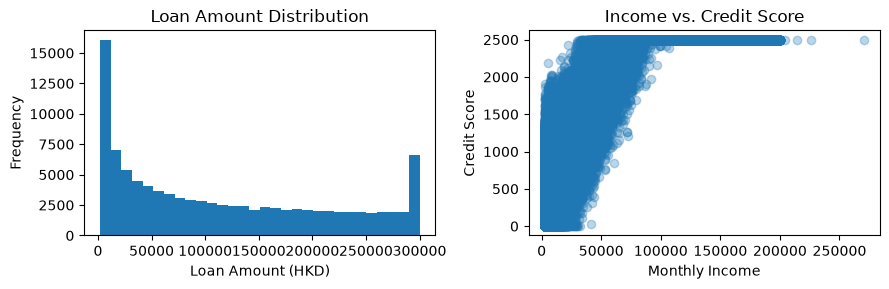

In [3]:
# Descriptive visualization
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].hist(fintech["loan_amount"].dropna(), bins=30)
axes[0].set_xlabel("Loan Amount (HKD)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Loan Amount Distribution")

axes[1].scatter(
    fintech["monthly_income"],
    fintech["credit_score"],
    alpha=0.3
)
axes[1].set_xlabel("Monthly Income")
axes[1].set_ylabel("Credit Score")
axes[1].set_title("Income vs. Credit Score")

plt.tight_layout()
plt.show()

In [4]:
# Test the observed relationship
corr_data = fintech[["monthly_income", "credit_score"]].dropna()
corr, p = stats.pearsonr(
    corr_data["monthly_income"],
    corr_data["credit_score"]
)

print(f"Pearson r: {corr:.3f}")
if p < 1e-300:
    print("p-value: < 1e-300")
else:
    print(f"p-value: {p:.2e}")
# The scatterplot suggests a ceiling effect near a credit score of 2,500.

Pearson r: 0.818
p-value: < 1e-300


In [4]:
# Classify automated decisions from approval records
fintech["automatic_approved"] = pd.Series(
    np.nan, index=fintech.index, dtype="object"
)

fintech.loc[
    (fintech["approved"] == "t") &
    (fintech["manual_approved"].isna()),
    "automatic_approved"
] = "t"

fintech.loc[
    (fintech["approved"] == "f") &
    (fintech["manual_approved"].isna()),
    "automatic_approved"
] = "f"

print("Automated approval:", (fintech["automatic_approved"] == "t").sum())
print("Automated rejection:", (fintech["automatic_approved"] == "f").sum())
print("Manual review:", fintech["automatic_approved"].isna().sum())

Automated approval: 13838
Automated rejection: 50236
Manual review: 35926


In [5]:
# Test whether applicant characteristics differ between automated approvals and rejections.
def compare_groups(data, variable):
    """Welch t-test p-value for one continuous variable."""
    approved = data.loc[
        data["automatic_approved"] == "t", variable
    ].dropna()
    rejected = data.loc[
        data["automatic_approved"] == "f", variable
    ].dropna()

    return stats.ttest_ind(
        approved, rejected, equal_var=False
    ).pvalue


variables = [
    "loan_amount", "tenor", "age",
    "month_of_service", "monthly_income",
    "credit_score", "friends_facebook"
]

for v in variables:
    print(f"{v}: p = {compare_groups(fintech, v):.2e}")

loan_amount: p = 9.66e-01
tenor: p = 7.72e-01
age: p = 3.34e-06
month_of_service: p = 2.16e-176
monthly_income: p = 0.00e+00
credit_score: p = 0.00e+00
friends_facebook: p = 9.84e-01


In [6]:
# Predict automated approval
# Exclude manual-review cases from the binary target.
analysis_data = fintech[
    fintech["automatic_approved"].isin(["t", "f"])
].copy()

analysis_data["automatic_approved_dummy"] = (
    analysis_data["automatic_approved"] == "t"
).astype(int)

features = [
    "loan_amount", "tenor", "age",
    "month_of_service", "monthly_income",
    "credit_score", "currently_employed"
]

model_data = analysis_data[
    ["automatic_approved_dummy"] + features
].dropna()

model_data = pd.get_dummies(
    model_data,
    columns=["currently_employed"],
    drop_first=True,
    dtype=int
)

X = model_data.drop(columns="automatic_approved_dummy")
y = model_data["automatic_approved_dummy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
tree.fit(X_train, y_train)

print(classification_report(
    y_test,
    tree.predict(X_test),
    digits=2
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10047
           1       1.00      1.00      1.00      2768

    accuracy                           1.00     12815
   macro avg       1.00      1.00      1.00     12815
weighted avg       1.00      1.00      1.00     12815



In [10]:
# Feature importance
importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

# Near-perfect performance indicates rule leakage:
# automatic_approved is derived from the existing approval system,
# and credit_score alone reconstructs that rule. The tree is therefore
# recovering existing approval logic rather than learning generalizable
# patterns and should not be used as a new predictive model.

credit_score            1.0
tenor                   0.0
loan_amount             0.0
age                     0.0
month_of_service        0.0
monthly_income          0.0
currently_employed_t    0.0
dtype: float64
